In [1]:
!pip install yfinance
!pip install tensorflow

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 4.4 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.6 MB 2.5 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.8 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=96a7f897823d2b62926fae0d0e65194af4a01f6a3991fa27fe0c6300aad96671
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfull

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [3]:
# Fetch stock data
stock = "AAPL"

data = yf.download(stock, start="2015-01-01", end="2024-01-01")

# Display first rows
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214899,24.682231,23.776359,24.671157,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534933,23.794069,23.173912,23.596948,263188400
2015-01-07,23.864952,23.964619,23.632393,23.743135,160423600
2015-01-08,24.781897,24.839483,24.075361,24.192749,237458000


In [4]:
print(data.shape)

(2264, 5)


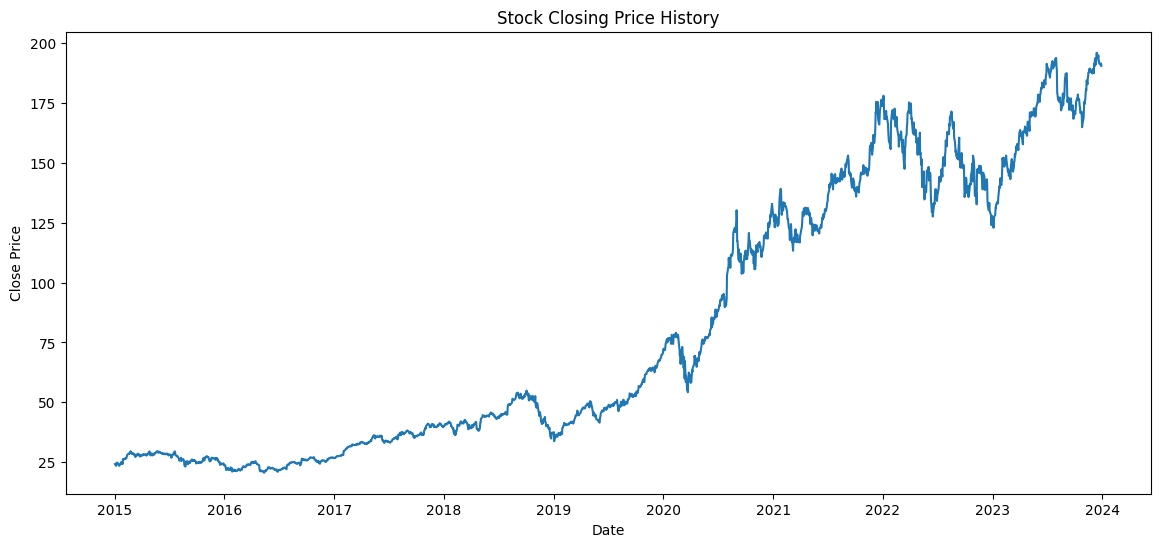

In [5]:
# Plot closing price history

plt.figure(figsize=(14,6))
plt.plot(data['Close'])
plt.title('Stock Closing Price History')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

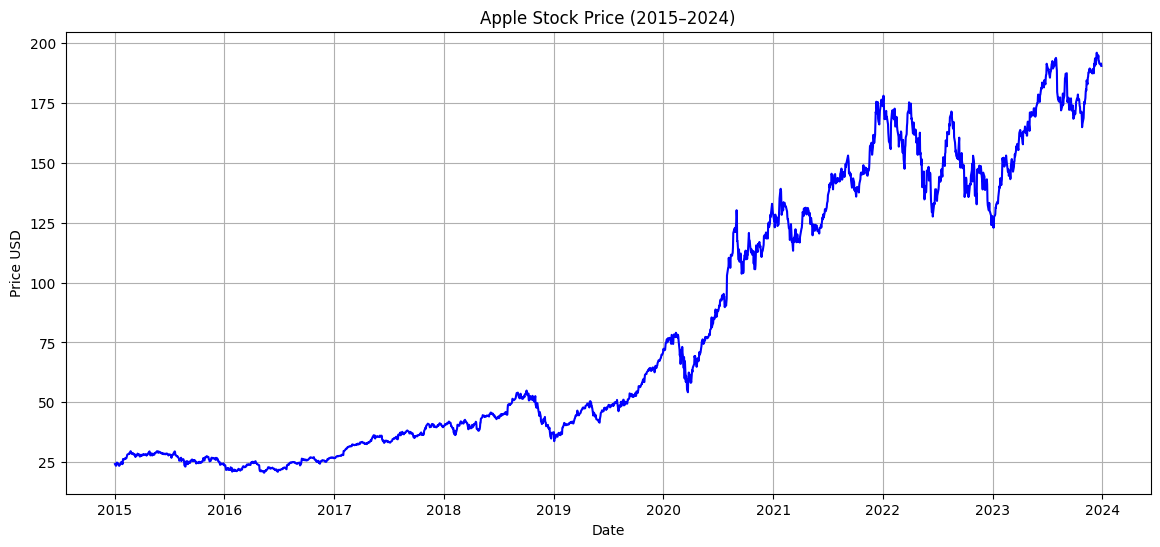

In [6]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'], color='blue')
plt.title('Apple Stock Price (2015–2024)')
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.grid()
plt.show()

In [7]:
# Select closing price
close_prices = data['Close']

# Convert to dataframe
close_prices = pd.DataFrame(close_prices)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_prices)

# Check first few values
scaled_data[:5]

array([[0.02068563],
       [0.01679832],
       [0.01681092],
       [0.01869149],
       [0.0239166 ]])

In [8]:
scaled_data.shape

(2264, 1)

In [9]:
# Create sequences for LSTM

sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

In [10]:
print(X.shape)
print(y.shape)

(2204, 60)
(2204,)


In [11]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [12]:
print(X.shape)

(2204, 60, 1)


In [13]:
# Build LSTM Model

model = Sequential()

# First LSTM Layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(units=1))

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the model

model.fit(
    X,
    y,
    epochs=20,
    batch_size=32
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 0.0177
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0027
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0026
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0022
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0019
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0020
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0021
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0019
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0023
Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0018
Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0016
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0018
Epoch 13/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0018
Epoch 14/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0017
Epoch 15/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0018
Epoc

In [17]:
# Predict stock prices
predictions = model.predict(X)

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


In [18]:
# Convert predictions back to original scale
predictions = scaler.inverse_transform(predictions)

# Convert actual values back
actual_prices = scaler.inverse_transform(y.reshape(-1,1))

In [19]:
print(predictions[:5])

[[26.989613]
 [26.950853]
 [26.909496]
 [26.886082]
 [26.908339]]


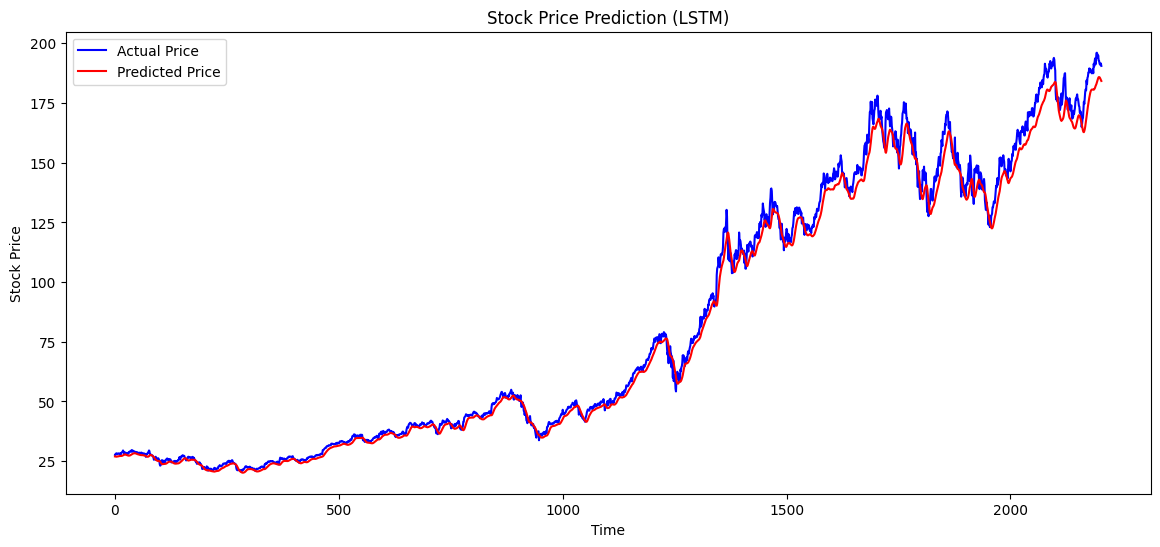

In [20]:
# Plot actual vs predicted prices

plt.figure(figsize=(14,6))

plt.plot(actual_prices, color='blue', label='Actual Price')
plt.plot(predictions, color='red', label='Predicted Price')

plt.title('Stock Price Prediction (LSTM)')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()

plt.show()

In [21]:
# Calculate Moving Averages

data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

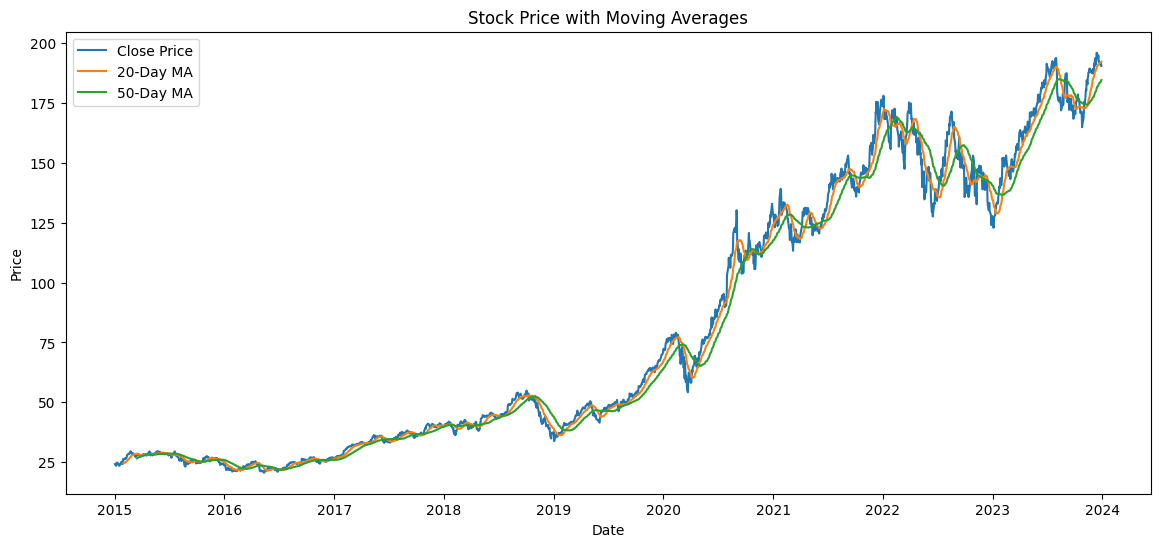

In [22]:
plt.figure(figsize=(14,6))

plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA20'], label='20-Day MA')
plt.plot(data['MA50'], label='50-Day MA')

plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

In [23]:
# Save predictions to dataframe

results = pd.DataFrame({
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predictions.flatten()
})

# Save to CSV
results.to_csv("stock_price_predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


In [24]:
# Save the trained LSTM model
model.save("lstm_stock_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [25]:
# Calculate RSI indicator

delta = data['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

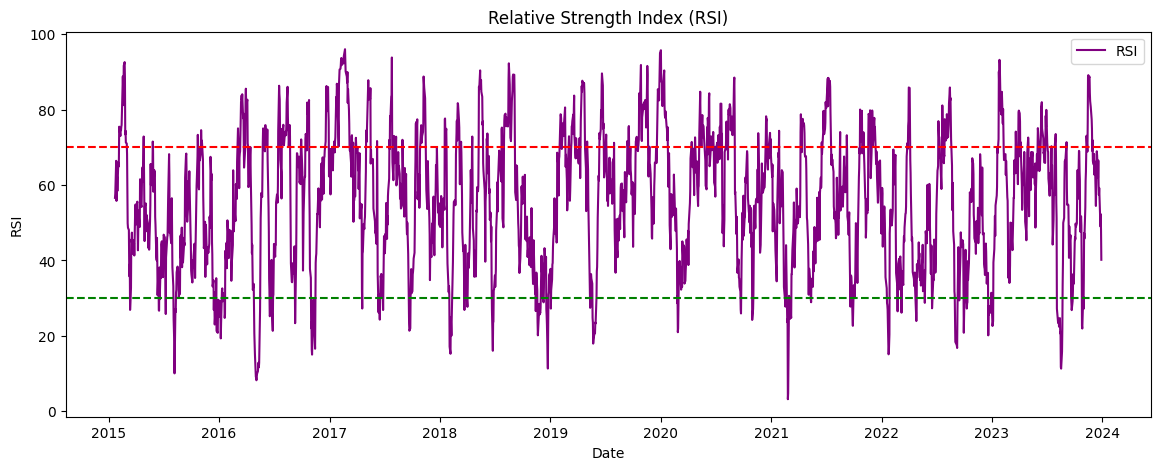

In [26]:
plt.figure(figsize=(14,5))
plt.plot(data['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

plt.title("Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.show()